## Prep: Google Drive + Sam3

In [1]:
!pip install numpy==1.26.4 # Install the version compatible with sam3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 require

In [1]:
# 1. Google Drive
from google.colab import drive
drive.mount('/content/drive')

skip_sam3 = False # Changed to False to enable SAM3 initialization
if not skip_sam3:
    # 2. Sam3 repo
    sam3_root = "drive/MyDrive/sam3/sam3" # sam3 설치 경로
    # !git clone https://github.com/facebookresearch/sam3.git && mv sam3 drive/MyDrive/
    !pip install drive/MyDrive/sam3 triton # Install sam3 and triton

    import torch
    import sys
    import os
    import matplotlib.pyplot as plt

    # 3. GPU 최적화 설정 (Ampere 아키텍처 이상 추천)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

    # 4. Sam3 libs
    import sam3
    from PIL import Image
    from sam3.model_builder import build_sam3_image_model
    from sam3.model.box_ops import box_xywh_to_cxcywh
    from sam3.model.sam3_image_processor import Sam3Processor
    from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

    # 5. Sam3 model
    from huggingface_hub import login
    login(token="hf_REDACTED")

    bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
    model = build_sam3_image_model(bpe_path=bpe_path)
    processor = Sam3Processor(model, confidence_threshold=0.5)

Mounted at /content/drive
Processing ./drive/MyDrive/sam3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.5 MB/s eta 0:00:00
  Created wheel for sam3: filename=sam3-0.1.0-py3-none-any.whl size=2035309 sha256=4d240f936c58879a87d399ba932e38c0493ca440a40146827905898da0b95412
  Stored in directory: /tmp/pip-ephem-wheel-cache-sd7y9vfs/wheels/a9/f6/56/8bceed5d64a938729b7cd9ea739ee815f543ed3684d47504b4
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=7a555a7345d442891fbe259d46a13999e79cdab78e154940a58c3b4ad714b030
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built sam3 iopath


/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

## EgoWaste DB
Load `meta_df`

In [2]:
import pandas as pd
import json

db_root = 'drive/MyDrive/camera1_plastics_shareable_dataset'
csv_file_path = f'{db_root}/camera1_plastics_meta2.csv'
original_external_root = '/media/jisha/E/trash_dataset/'
colab_equivalent_prefix = 'drive/MyDrive/'

try:
    meta_df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}'")
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{csv_file_path}' is empty.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'drive/MyDrive/camera1_plastics_shareable_dataset/camera1_plastics_meta2.csv'


### Comparing Multiple `detect_trash` Versions

To compare different versions of your detection logic, we can define separate functions (e.g., `detect_trash_v1`, `detect_trash_v2`) and run them sequentially or in parallel for the same input. The results from each version can then be stored and analyzed.

Let's define two simulated versions of `detect_trash` and modify the processing loop to execute both, storing their outcomes in separate lists.

Processing only the first 2 files for testing...
found 7 object(s)


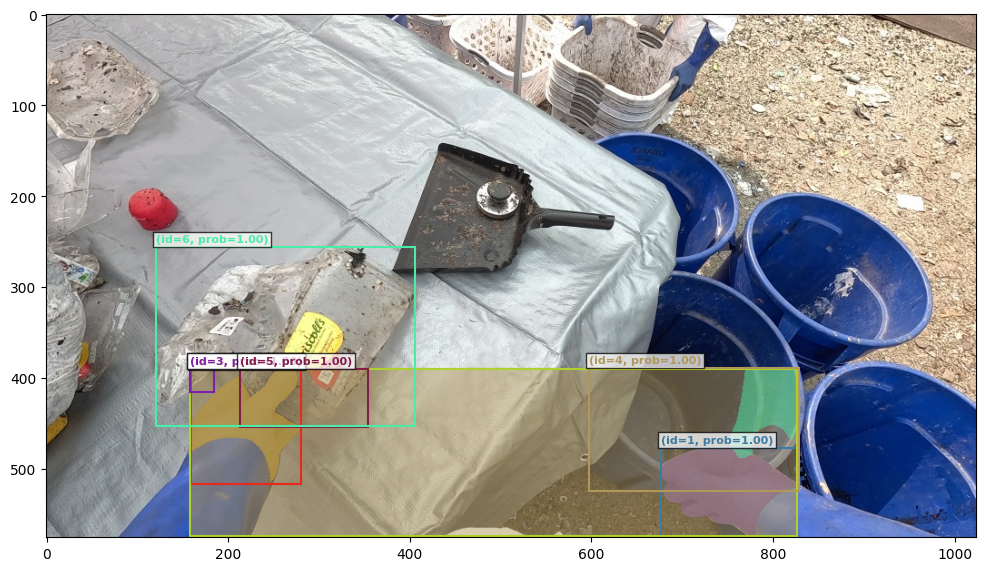

Processed item 1 with V1: {'frame_path': 'drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000018.jpg', 'clip_path': 'drive/MyDrive/camera1_plastics_shareable_dataset/audio_video_clips/GX010023/GX010023__000012.720__000014.120.mp4', 'hand_detections': [{'hand_bbox_original_coords': [158, 390, 280, 516]}, {'hand_bbox_original_coords': [676, 476, 826, 574]}], 'plastic_in_hand_region_detections': [{'hand_idx': -1, 'plastic_bbox_cropped_coords': [0, 0, 26, 25], 'plastic_bbox_original_coords': [158, 390, 184, 415], 'iou_mask_to_gt': tensor(0.0001, device='cuda:0')}, {'hand_idx': -1, 'plastic_bbox_cropped_coords': [439, -1, 670, 135], 'plastic_bbox_original_coords': [597, 389, 828, 525], 'iou_mask_to_gt': tensor(0., device='cuda:0')}, {'hand_idx': -1, 'plastic_bbox_cropped_coords': [55, 0, 196, 64], 'plastic_bbox_original_coords': [213, 390, 354, 454], 'iou_mask_to_gt': tensor(0.0078, device='cuda:0')}], 'detection_status_v1': 'processed_with_hands_and_plastic

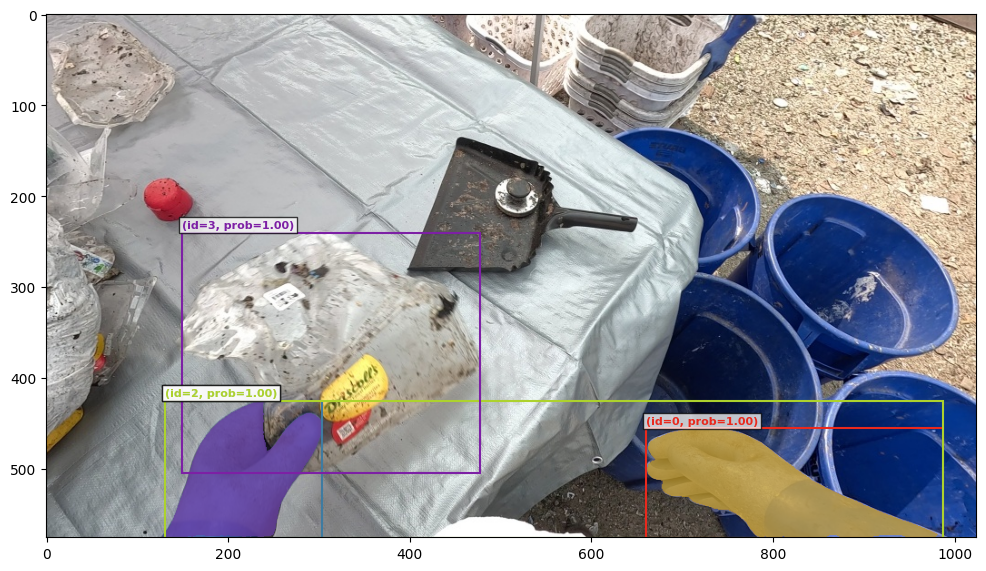

Processed item 2 with V1: {'frame_path': 'drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000019.jpg', 'clip_path': 'drive/MyDrive/camera1_plastics_shareable_dataset/audio_video_clips/GX010023/GX010023__000012.720__000014.120.mp4', 'hand_detections': [{'hand_bbox_original_coords': [660, 455, 987, 575]}, {'hand_bbox_original_coords': [130, 425, 303, 576]}], 'plastic_in_hand_region_detections': [], 'detection_status_v1': 'no_plastic_in_combined_hand_region'}
Processed item 2 with V2: {'frame_path': 'drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000019.jpg', 'clip_path': 'drive/MyDrive/camera1_plastics_shareable_dataset/audio_video_clips/GX010023/GX010023__000012.720__000014.120.mp4', 'detection_status_v2': 'processed_by_v2', 'detected_objects_v2': ['plastic_bag', 'glass_bottle'], 'simulated_mask_output_v2': 'path/to/simulated_mask_v2.png'}
Stopped after processing 2 files as per test_limit.
Stopped after processing 2 fil

In [10]:
import os
import torch
from PIL import Image
import numpy as np # Added for converting torch tensors to numpy for Image.fromarray
import torch.nn.functional as F # Import for resizing masks

def compute_mask_iou(mask1: torch.Tensor, mask2: torch.Tensor) -> float:
    """
    Computes IoU between two binary masks.
    Args:
        mask1 (torch.Tensor): Binary mask tensor (H, W).
        mask2 (torch.Tensor): Binary mask tensor (H, W).
    Returns:
        float: IoU score.
    """
    # Ensure masks are boolean for logical operations
    mask1 = mask1.bool()
    mask2 = mask2.bool()

    intersection = torch.logical_and(mask1, mask2).sum()
    union = torch.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection.float() / union.float()

testPrompt = "hands"
def detect_trash_v1(frame_path, clip_path, expected_mask_path):
    results_v1 = {
        'frame_path': frame_path,
        'clip_path': clip_path,
        'hand_detections': [],
        'plastic_in_hand_region_detections': [],
        'detection_status_v1': 'failed'
    }

    try:
        img_pil = Image.open(frame_path)
        original_width, original_height = img_pil.size

        # --- Load Ground Truth Mask ---
        ground_truth_mask_tensor = None
        if expected_mask_path and os.path.exists(expected_mask_path):
            gt_mask_pil = Image.open(expected_mask_path).convert('L') # Convert to grayscale
            if gt_mask_pil.size != img_pil.size:
                gt_mask_pil = gt_mask_pil.resize(img_pil.size, Image.NEAREST) # Resize to match original image
            ground_truth_mask_tensor = torch.from_numpy(np.array(gt_mask_pil)).bool().to(processor.device)
            # Ensure it's on the same device as other tensors for IoU calculation

        # --- Step 1: Detect hands ---
        inference_state_hands = processor.set_image(img_pil)
        inference_state_hands = processor.set_text_prompt(state=inference_state_hands, prompt=testPrompt)

        hand_pred_boxes_raw = inference_state_hands.get('boxes', None)
        hand_masks_raw = inference_state_hands.get('masks', None)

        largest_hand_boxes = []
        largest_hand_masks = []

        # Initialize combined hand region to full image in case no hands are detected
        xmin_combined_hand, ymin_combined_hand = 0, 0
        xmax_combined_hand, ymax_combined_hand = original_width, original_height

        if hand_pred_boxes_raw is None or len(hand_pred_boxes_raw) == 0:
            results_v1['detection_status_v1'] = 'no_hands_detected'
        else:
            # Calculate area for each hand bounding box
            hand_areas = (hand_pred_boxes_raw[:, 2] - hand_pred_boxes_raw[:, 0]) * \
                         (hand_pred_boxes_raw[:, 3] - hand_pred_boxes_raw[:, 1])

            # Sort hand bounding boxes by area and select the top 2
            sorted_indices = torch.argsort(hand_areas, descending=True)
            top_n_hands = min(2, len(hand_pred_boxes_raw))
            largest_hand_boxes = hand_pred_boxes_raw[sorted_indices[:top_n_hands]]
            largest_hand_masks = [hand_masks_raw[i] for i in sorted_indices[:top_n_hands]] # masks are already for original image

            # Calculate combined bounding box for largest hands
            xmin_combined_hand = torch.min(largest_hand_boxes[:, 0]).int().item()
            ymin_combined_hand = torch.min(largest_hand_boxes[:, 1]).int().item()
            xmax_combined_hand = torch.max(largest_hand_boxes[:, 2]).int().item()
            ymax_combined_hand = torch.max(largest_hand_boxes[:, 3]).int().item()

            # Ensure coordinates are within image bounds for cropping
            xmin_combined_hand = max(0, xmin_combined_hand)
            ymin_combined_hand = max(0, ymin_combined_hand)
            xmax_combined_hand = min(original_width, xmax_combined_hand)
            ymax_combined_hand = min(original_height, ymax_combined_hand)

            for i, hand_bbox_xyxy in enumerate(largest_hand_boxes):
                results_v1['hand_detections'].append({
                    'hand_bbox_original_coords': hand_bbox_xyxy.int().tolist()
                })

        cropped_img_pil = img_pil.crop((xmin_combined_hand, ymin_combined_hand, xmax_combined_hand, ymax_combined_hand))

        # --- Step 2: Detect plastic objects in combined hand region (or whole image if no hands) ---
        inference_state_plastic = processor.set_image(cropped_img_pil)
        inference_state_plastic = processor.set_text_prompt(state=inference_state_plastic, prompt="plastic object")

        plastic_pred_boxes_cropped = inference_state_plastic.get('boxes', None)
        plastic_masks_cropped = inference_state_plastic.get('masks', None)

        if plastic_pred_boxes_cropped is not None and len(plastic_pred_boxes_cropped) > 0:
            for j, plastic_bbox_cropped_xyxy in enumerate(plastic_pred_boxes_cropped):
                plastic_mask_tensor_cropped = plastic_masks_cropped[j]

                # Convert cropped plastic bbox coords back to original image coords
                p_xmin_cropped, p_ymin_cropped, p_xmax_cropped, p_ymax_cropped = plastic_bbox_cropped_xyxy.int().tolist()
                p_xmin_orig = p_xmin_cropped + xmin_combined_hand
                p_ymin_orig = p_ymin_cropped + ymin_combined_hand
                p_xmax_orig = p_xmax_cropped + xmin_combined_hand
                p_ymax_orig = p_ymax_cropped + ymin_combined_hand
                plastic_bbox_original_coords = [p_xmin_orig, p_ymin_orig, p_xmax_orig, p_ymax_orig]

                # Calculate target dimensions for the mask in original coordinates
                target_height = p_ymax_orig - p_ymin_orig
                target_width = p_xmax_orig - p_xmin_orig

                # Ensure the cropped mask tensor is 2D (H,W)
                if plastic_mask_tensor_cropped.ndim == 3: # If it's (1, H, W)
                    cropped_mask_2d = plastic_mask_tensor_cropped.squeeze(0).float() # Convert to float for F.interpolate
                else: # If it's already (H, W)
                    cropped_mask_2d = plastic_mask_tensor_cropped.float()

                # Resize the cropped mask to the target dimensions using F.interpolate
                resized_cropped_mask_2d = F.interpolate(
                    cropped_mask_2d.unsqueeze(0).unsqueeze(0), # Add batch and channel dims for interpolate
                    size=(target_height, target_width),
                    mode='nearest' # Use nearest for binary masks
                ).squeeze(0).squeeze(0).bool() # Remove added dims and convert back to bool

                full_size_plastic_mask_tensor = torch.zeros(
                    original_height, original_width,
                    dtype=torch.bool, device=plastic_mask_tensor_cropped.device
                )

                # Place the resized cropped mask into the full-sized mask at the correct offset
                full_size_plastic_mask_tensor[
                    p_ymin_orig : p_ymax_orig,
                    p_xmin_orig : p_xmax_orig
                ] = resized_cropped_mask_2d

                iou_score_mask_to_gt = -1.0 # Default if no GT mask
                if ground_truth_mask_tensor is not None:
                    iou_score_mask_to_gt = compute_mask_iou(full_size_plastic_mask_tensor, ground_truth_mask_tensor)

                results_v1['plastic_in_hand_region_detections'].append({
                    'hand_idx': -1, # No longer tied to a single hand, but the combined region
                    'plastic_bbox_cropped_coords': [p_xmin_cropped, p_ymin_cropped, p_xmax_cropped, p_ymax_cropped],
                    'plastic_bbox_original_coords': plastic_bbox_original_coords,
                    'iou_mask_to_gt': iou_score_mask_to_gt
                })

            results_v1['detection_status_v1'] = 'processed_with_hands_and_plastic' if len(largest_hand_boxes) > 0 else 'processed_with_plastic'
        else:
             results_v1['detection_status_v1'] = 'no_plastic_in_combined_hand_region' if len(largest_hand_boxes) > 0 else 'no_plastic_in_image'

        # --- Visualization ---
        all_pred_boxes = []
        all_masks = []
        all_labels = []
        all_scores = [] # Initialize list for scores

        # Add individual hand detections
        if largest_hand_boxes is not None and len(largest_hand_boxes) > 0:
            for i, hand_box in enumerate(largest_hand_boxes):
                all_pred_boxes.append(hand_box.unsqueeze(0)) # Add as (1,4) tensor
                all_labels.append(f"Hand {i}")
                all_masks.extend([mask.bool() for mask in largest_hand_masks])
                all_scores.append(torch.tensor([1.0], device=processor.device)) # Placeholder score

            # Add the combined hand region bounding box for visualization
            combined_hand_bbox_tensor = torch.tensor([[xmin_combined_hand, ymin_combined_hand, xmax_combined_hand, ymax_combined_hand]], dtype=torch.float32, device=processor.device)
            all_pred_boxes.append(combined_hand_bbox_tensor)

            combined_hand_mask_tensor = torch.zeros(original_height, original_width, dtype=torch.bool, device=processor.device)
            combined_hand_mask_tensor[ymin_combined_hand:ymax_combined_hand, xmin_combined_hand:xmax_combined_hand] = True
            all_masks.append(combined_hand_mask_tensor.unsqueeze(0))

            all_labels.append("Combined Hand Region")
            all_scores.append(torch.tensor([1.0], device=processor.device)) # Placeholder score


        # Add plastic detections
        if plastic_pred_boxes_cropped is not None and len(plastic_pred_boxes_cropped) > 0:
            for j, plastic_bbox_cropped_xyxy in enumerate(plastic_pred_boxes_cropped):
                p_xmin_cropped, p_ymin_cropped, p_xmax_cropped, p_ymax_cropped = plastic_bbox_cropped_xyxy.int().tolist()
                p_xmin_orig = p_xmin_cropped + xmin_combined_hand
                p_ymin_orig = p_ymin_cropped + ymin_combined_hand
                p_xmax_orig = p_xmax_cropped + xmin_combined_hand
                p_ymax_orig = p_ymax_cropped + ymin_combined_hand
                all_pred_boxes.append(torch.tensor([[p_xmin_orig, p_ymin_orig, p_xmax_orig, p_ymax_orig]], dtype=torch.float32, device=plastic_bbox_cropped_xyxy.device))

                # Recreate full size plastic mask for visualization
                plastic_mask_tensor_cropped = plastic_masks_cropped[j]

                target_height_vis = p_ymax_orig - p_ymin_orig
                target_width_vis = p_xmax_orig - p_xmin_orig

                if plastic_mask_tensor_cropped.ndim == 3:
                    cropped_mask_2d_vis = plastic_mask_tensor_cropped.squeeze(0).float()
                else:
                    cropped_mask_2d_vis = plastic_mask_tensor_cropped.float()

                resized_cropped_mask_2d_vis = F.interpolate(
                    cropped_mask_2d_vis.unsqueeze(0).unsqueeze(0),
                    size=(target_height_vis, target_width_vis),
                    mode='nearest'
                ).squeeze(0).squeeze(0).bool()

                full_size_plastic_mask_tensor_vis = torch.zeros(
                    original_height, original_width,
                    dtype=torch.bool, device=plastic_mask_tensor_cropped.device
                )

                full_size_plastic_mask_tensor_vis[p_ymin_orig : p_ymax_orig, p_xmin_orig : p_xmax_orig] = resized_cropped_mask_2d_vis

                all_masks.append(full_size_plastic_mask_tensor_vis.unsqueeze(0))

                # Get IoU value from results_v1 for labeling
                iou_val = results_v1['plastic_in_hand_region_detections'][j]['iou_mask_to_gt']
                all_labels.append(f"Plastic {j} (IoU GT: {iou_val:.2f})")
                all_scores.append(torch.tensor([1.0], device=processor.device)) # Placeholder score

        # Add ground truth mask (if available)
        if ground_truth_mask_tensor is not None:
            nonzero_coords_gt = torch.nonzero(ground_truth_mask_tensor)
            if nonzero_coords_gt.shape[0] > 0:
                gt_ymin, gt_xmin = torch.min(nonzero_coords_gt, dim=0)[0]
                gt_ymax, gt_xmax = torch.max(nonzero_coords_gt, dim=0)[0]
                gt_bbox = torch.tensor([[gt_xmin, gt_ymin, gt_xmax, gt_ymax]], dtype=torch.float32, device=ground_truth_mask_tensor.device)
                all_pred_boxes.append(gt_bbox)
                all_masks.append(ground_truth_mask_tensor.bool().unsqueeze(0))
                all_labels.append("GT Mask")
                all_scores.append(torch.tensor([1.0], device=processor.device)) # Placeholder score

        if len(all_pred_boxes) > 0:
            final_pred_boxes_tensor = torch.cat(all_pred_boxes, dim=0)
            stacked_all_masks = torch.stack(all_masks).float() if all_masks else torch.empty(0, 1, original_height, original_width, device=processor.device)
            final_scores_tensor = torch.cat(all_scores, dim=0) if all_scores else torch.empty(0, device=processor.device)

            plot_results_dict = {
                'boxes': final_pred_boxes_tensor,
                'masks': stacked_all_masks,
                'phrases': all_labels,
                'scores': final_scores_tensor
            }
            fig = plot_results(img_pil, plot_results_dict)
            plt.show()
        else:
            print("No detections or ground truth to visualize.")

    except Exception as e:
        results_v1['detection_status_v1'] = f'error: {e}'
        print(f"Error processing {frame_path}: {e}")

    return results_v1

def detect_trash_v2(frame_path, clip_path, expected_mask_path):
    """
    Simulated Version 2 of the trash detection function.
    """
    simulated_result = {
        'frame_path': frame_path,
        'clip_path': clip_path,
        'detection_status_v2': 'processed_by_v2',
        'detected_objects_v2': ['plastic_bag', 'glass_bottle'],
        'simulated_mask_output_v2': 'path/to/simulated_mask_v2.png' # Placeholder
    }
    # print(f"Simulating V2 detection for frame: {os.path.basename(frame_path)}")
    return simulated_result

def process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root):
    """
    Processes a raw frame file suffix to construct a full, accessible frame path.

    Args:
        frame_file_suffix (str): The suffix or full path of the frame file.
        original_external_root (str): The original external root directory.
        colab_equivalent_prefix (str): The Colab equivalent prefix for paths.
        db_root (str): The root directory of the database.

    Returns:
        str: The full, processed path to the frame file.
    """
    # Process frame path
    if frame_file_suffix.startswith(original_external_root):
        frame_path_temp = frame_file_suffix.replace(original_external_root, colab_equivalent_prefix)
    else:
        frame_path_temp = frame_file_suffix

    if frame_path_temp.startswith(db_root):
        relative_part_frame = frame_path_temp[len(db_root):]
        if relative_part_frame.startswith('/') or relative_part_frame.startswith('\\'):
            relative_part_frame = relative_part_frame[1:]
        full_frame_path = os.path.join(db_root, relative_part_frame)
    else:
        full_frame_path = os.path.join(db_root, frame_path_temp)

    return full_frame_path

detection_results_v1 = []
detection_results_v2 = []

# Set test_limit to an integer (e.g., 5) to process only the first N files.
# Set test_limit = None to process all files in meta_df.
test_limit = 2 # Change to None to process all files

if test_limit is not None:
    print(f"Processing only the first {test_limit} files for testing...")
else:
    print("Processing all files...")

# Iterate through each row of the meta_df DataFrame
for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        print(f"Stopped after processing {test_limit} files as per test_limit.")
        break

    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    clip_file_suffix = row['timestamp_clip_path']

    # Use the helper function to process paths
    full_frame_path = process_frame_path(
        frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root
    )

    full_mask_path = None
    if pd.notna(mask_file_suffix):
        full_mask_path = process_frame_path(
            mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root
        )

    full_clip_path = None
    if pd.notna(clip_file_suffix):
        full_clip_path = process_frame_path(
            clip_file_suffix, original_external_root, colab_equivalent_prefix, db_root
        )

    # Call both versions of the detect_trash function
    result_v1 = detect_trash_v1(full_frame_path, full_clip_path, full_mask_path)
    result_v2 = detect_trash_v2(full_frame_path, full_clip_path, full_mask_path)

    detection_results_v1.append(result_v1)
    detection_results_v2.append(result_v2)

    # Print progress
    if test_limit is None and (index + 1) % 100 == 0:
        print(f"Processed {index + 1} items...")
    elif test_limit is not None:
        print(f"Processed item {index+1} with V1: {result_v1}")
        print(f"Processed item {index+1} with V2: {result_v2}")

if test_limit is not None:
    print(f"Stopped after processing {len(detection_results_v1)} files as per test_limit.")

# Display summary of results
print(f"\nTotal items processed by V1: {len(detection_results_v1)}")
print(f"Total items processed by V2: {len(detection_results_v2)}")

# To see the results, you can uncomment these lines:
# display(pd.DataFrame(detection_results_v1).head())
# display(pd.DataFrame(detection_results_v2).head())

In [5]:
import torch

def compute_mask_to_bbox_iou(gt_mask: torch.Tensor, pred_bboxes: torch.Tensor) -> torch.Tensor:
    """
    Computes IoU between a Ground Truth Binary Mask and one or more Predicted Bounding Boxes.

    Args:
        gt_mask (torch.Tensor): Binary mask tensor of shape (H, W), values are 0 or 1.
        pred_bboxes (torch.Tensor): Predicted boxes tensor of shape (N, 4) in [xmin, ymin, xmax, ymax] format.

    Returns:
        torch.Tensor: IoU scores tensor of shape (N,) for each predicted bounding box.
    """
    # 1. CONVERT MASK TO BBOX
    # Find all pixel coordinates where the mask is active (equal to 1)
    nonzero_coords = torch.nonzero(gt_mask)

    if nonzero_coords.shape[0] == 0:
        # Handle edge case where the ground truth mask is completely empty
        return torch.zeros(pred_bboxes.shape[0], device=pred_bboxes.device)

    # Extract tight boundary coordinates from the mask: [xmin, ymin, xmax, ymax]
    ymin, xmin = torch.min(nonzero_coords, dim=0)[0]
    ymax, xmax = torch.max(nonzero_coords, dim=0)[0]

    # Create the ground truth box tensor and match the shape to predictions (1, 4)
    gt_bbox = torch.tensor([xmin, ymin, xmax, ymax], dtype=torch.float32, device=pred_bboxes.device).unsqueeze(0)

    # 2. COMPUTE INTERSECTION
    # Compute the overlapping coordinate boundaries
    inter_xmin = torch.max(gt_bbox[:, 0], pred_bboxes[:, 0])
    inter_ymin = torch.max(gt_bbox[:, 1], pred_bboxes[:, 1])
    inter_xmax = torch.min(gt_bbox[:, 2], pred_bboxes[:, 2])
    inter_ymax = torch.min(gt_bbox[:, 3], pred_bboxes[:, 3])

    # Calculate width and height of intersection, clamping negative values to 0
    inter_w = torch.clamp(inter_xmax - inter_xmin, min=0)
    inter_h = torch.clamp(inter_ymax - inter_ymin, min=0)
    intersection_area = inter_w * inter_h

    # 3. COMPUTE UNION
    # Calculate individual areas of the boxes
    gt_area = (gt_bbox[:, 2] - gt_bbox[:, 0]) * (gt_bbox[:, 3] - gt_bbox[:, 1])
    pred_areas = (pred_bboxes[:, 2] - pred_bboxes[:, 0]) * (pred_bboxes[:, 3] - pred_bboxes[:, 1])

    # Formula: Union = Area A + Area B - Intersection
    union_area = gt_area + pred_areas - intersection_area

    # 4. CALCULATE IoU
    # Avoid division by zero by adding a microscopic epsilon value
    iou = intersection_area / (union_area + 1e-7)

    return iou

def compute_mask_iou(mask1: torch.Tensor, mask2: torch.Tensor) -> float:
    """
    Computes IoU between two binary masks.
    Args:
        mask1 (torch.Tensor): Binary mask tensor (H, W).
        mask2 (torch.Tensor): Binary mask tensor (H, W).
    Returns:
        float: IoU score.
    """
    # Ensure masks are boolean for logical operations
    mask1 = mask1.bool()
    mask2 = mask2.bool()

    intersection = torch.logical_and(mask1, mask2).sum()
    union = torch.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection.float() / union.float()


### IoU Metrics Comparison

Let's analyze the Intersection over Union (IoU) scores for plastic object detections relative to the ground truth masks. This will provide insights into the accuracy of our `detect_trash_v1` function.

In [7]:
import numpy as np

all_iou_scores = []

for result in detection_results_v1:
    for plastic_detection in result['plastic_in_hand_region_detections']:
        # Ensure IoU is a scalar and convert to float if it's a tensor
        iou_score = plastic_detection['iou_mask_to_gt']
        if isinstance(iou_score, torch.Tensor):
            iou_score = iou_score.item()
        all_iou_scores.append(iou_score)

if all_iou_scores:
    iou_array = np.array(all_iou_scores)

    print(f"Total plastic detections with IoU: {len(iou_array)}")
    print(f"Mean IoU: {iou_array.mean():.4f}")
    print(f"Median IoU: {np.median(iou_array):.4f}")
    print(f"Min IoU: {iou_array.min():.4f}")
    print(f"Max IoU: {iou_array.max():.4f}")
    print(f"Standard Deviation of IoU: {iou_array.std():.4f}")

    # Count detections by IoU range
    bins = [0, 0.25, 0.5, 0.75, 1.0]
    labels = ['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0']
    iou_categories = pd.cut(iou_array, bins=bins, labels=labels, right=False)
    print("\nIoU Distribution:")
    print(iou_categories.value_counts().sort_index())
else:
    print("No plastic detections with IoU scores to analyze.")

Total plastic detections with IoU: 3
Mean IoU: 0.0026
Median IoU: 0.0001
Min IoU: 0.0000
Max IoU: 0.0078
Standard Deviation of IoU: 0.0036

IoU Distribution:
0-0.25      3
0.25-0.5    0
0.5-0.75    0
0.75-1.0    0
Name: count, dtype: int64


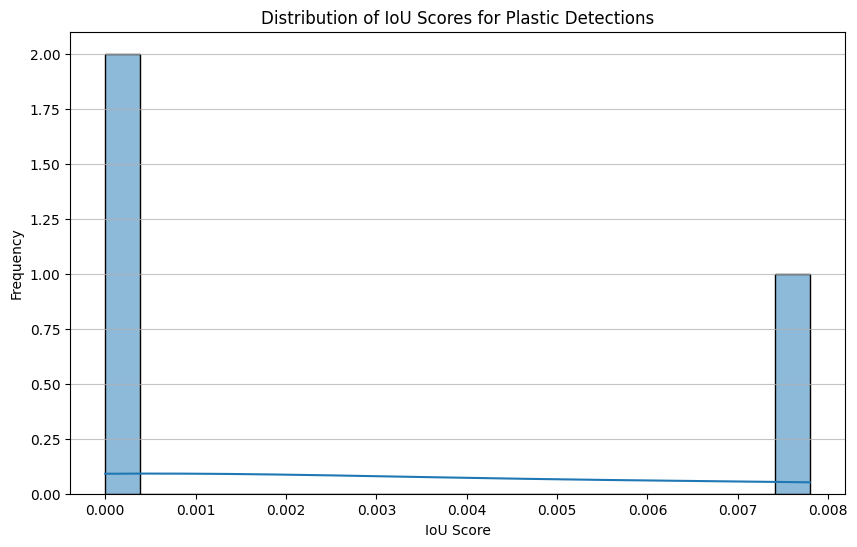

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

if all_iou_scores:
    plt.figure(figsize=(10, 6))
    sns.histplot(iou_array, bins=20, kde=True)
    plt.title('Distribution of IoU Scores for Plastic Detections')
    plt.xlabel('IoU Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No IoU scores to visualize.")